In [ ]:
# ================================================================
# 1. 10종 생활 쓰레기 CNN 데이터셋 통합 전처리
# ================================================================
#
# 최종 10개 클래스
#
# 0. battery   : 배터리
# 1. cardboard : 카드보드
# 2. clothes   : 의류
# 3. food      : 음식물·생물성 쓰레기
# 4. glass     : 유리
# 5. metal     : 금속
# 6. paper     : 종이
# 7. plastic   : 플라스틱
# 8. shoes     : 신발
# 9. trash     : 일반 쓰레기
#
# 데이터셋 1
# asdasdasasdas/garbage-classification
#
# 데이터셋 2
# sumn2u/garbage-classification-v2
#
# ================================================================


# ================================================================
# 1-1. 필요한 라이브러리 설치
# ================================================================

import sys
import subprocess

print("1-1. 필요한 라이브러리를 설치합니다.")

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "kaggle",
        "python-dotenv",
        "pillow"
    ],
    check=True
)

print("1-1. 라이브러리 설치 완료\n")



1-1. 필요한 라이브러리를 설치합니다.
1-1. 라이브러리 설치 완료



In [ ]:

# ================================================================
# 1-2. 필요한 라이브러리 불러오기
# ================================================================

print("1-2. 라이브러리를 불러옵니다.")

import os
import json
import shutil
import hashlib
import zipfile
import getpass
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image
from dotenv import load_dotenv
from google.colab import drive, files

print("1-2. 라이브러리 불러오기 완료\n")



1-2. 라이브러리를 불러옵니다.
1-2. 라이브러리 불러오기 완료



In [ ]:
from google.colab import drive, files
# ================================================================
# 2. Google Drive 연결
# ================================================================

print("2. Google Drive를 연결합니다.")

drive.mount(
    "/content/drive",
    force_remount=False
)

print("2. Google Drive 연결 완료\n")



2. Google Drive를 연결합니다.
Mounted at /content/drive
2. Google Drive 연결 완료



In [ ]:

# ================================================================
# 3. 프로젝트 기본 경로 설정
# ================================================================

print("3. 프로젝트 폴더를 설정합니다.")

# 3-1. Google Drive에 보존할 프로젝트 폴더
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/CNN_Garbage_TEST"
)

# 3-2. 원본 ZIP 파일 저장 폴더
DRIVE_ZIP_DIR = (
    DRIVE_ROOT / "original_zip"
)

# 3-3. 최종 10종 데이터셋 저장 폴더
DRIVE_MERGED_DIR = (
    DRIVE_ROOT / "merged_10class"
)

# 3-4. Colab 임시 작업 폴더
LOCAL_ROOT = Path(
    "/content/garbage_project"
)

# 3-5. 데이터셋별 압축 해제 폴더
DATASET1_DIR = (
    LOCAL_ROOT / "dataset1"
)

DATASET2_DIR = (
    LOCAL_ROOT / "dataset2"
)

# 3-6. 최종 병합 폴더
MERGED_DIR = (
    LOCAL_ROOT / "merged_10class"
)

# 3-7. 필요한 폴더 생성
DRIVE_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

DRIVE_ZIP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("3-1. Drive 프로젝트 폴더:")
print(DRIVE_ROOT)

print("\n3-2. Colab 작업 폴더:")
print(LOCAL_ROOT)

print("\n3. 프로젝트 폴더 설정 완료\n")



3. 프로젝트 폴더를 설정합니다.
3-1. Drive 프로젝트 폴더:
/content/drive/MyDrive/CNN_Garbage_TEST

3-2. Colab 작업 폴더:
/content/garbage_project

3. 프로젝트 폴더 설정 완료



In [ ]:
# ================================================================
# 4. Kaggle API 인증
# ================================================================

print("4. Kaggle API 인증을 시작합니다.")

import os
from pathlib import Path
from google.colab import files
from dotenv import load_dotenv

env_path = Path("/content/kaggle.env")

# 1. kaggle.env 파일이 없을 경우 업로드 요청
if not env_path.exists():
    print("kaggle.env 파일을 업로드해주세요.")
    uploaded = files.upload()

# 2. .env 파일 로드하여 환경변수 등록
if env_path.exists():
    load_dotenv(dotenv_path=env_path, override=True)
    print("환경변수 로드 완료!")
    print(f"KAGGLE_USERNAME: {os.environ.get('KAGGLE_USERNAME')}")
else:
    raise FileNotFoundError("kaggle.env 파일이 업로드되지 않았습니다.")


4. Kaggle API 인증을 시작합니다.
kaggle.env 파일을 업로드해주세요.


Saving kaggle.env to kaggle.env
환경변수 로드 완료!
KAGGLE_USERNAME: lilyjeongwon


In [ ]:
# ----------------------------------------------------------------
# 4-1. 이미 설정된 환경변수 확인
# ----------------------------------------------------------------

authenticated = False

if os.environ.get("KAGGLE_API_TOKEN"):
    print(
        "4-1. KAGGLE_API_TOKEN 환경변수를 찾았습니다."
    )
    authenticated = True

elif (
    os.environ.get("KAGGLE_USERNAME")
    and os.environ.get("KAGGLE_KEY")
):
    print(
        "4-1. 기존 Kaggle username/key 환경변수를 찾았습니다."
    )
    authenticated = True


# ----------------------------------------------------------------
# 4-2. .env.local 파일 자동 탐색
# ----------------------------------------------------------------

if not authenticated:

    possible_env_paths = [
        Path("/content/.env.local"),
        Path("/content/kaggle_token.env"),
        Path("/content/kaggle.env")
    ]

    env_path = None

    for possible_path in possible_env_paths:
        if possible_path.exists():
            env_path = possible_path
            break

    # 4-2-1. 파일이 없으면 업로드 요청
    if env_path is None:

        print(
            "4-2-1. Kaggle 인증 파일을 업로드하세요."
        )

        print(
            "지원 파일: .env.local, kaggle.json, "
            "kaggle_token.env"
        )

        uploaded_files = files.upload()

        if len(uploaded_files) == 0:
            raise RuntimeError(
                "Kaggle 인증 파일이 업로드되지 않았습니다."
            )

        uploaded_name = list(
            uploaded_files.keys()
        )[0]

        env_path = (
            Path("/content") /
            uploaded_name
        )

    print(
        "4-2. 인증 파일을 찾았습니다:",
        env_path.name
    )

4-1. 기존 Kaggle username/key 환경변수를 찾았습니다.


In [ ]:

import subprocess  # subprocess 모듈 임포트 추가
# ----------------------------------------------------------------
# 4-3. Kaggle 인증 테스트
# ----------------------------------------------------------------

print("4-5. Kaggle 인증을 확인합니다.")

# Kaggle API를 통해 쓰레기 분류 데이터셋 목록을 검색하는 명령
auth_test = subprocess.run(
    [
        "kaggle",
        "datasets",
        "list",
        "-s",
        "garbage classification"
    ],
    capture_output=True,
    text=True
)

if auth_test.returncode != 0:

    print(
        "Kaggle 인증 오류 내용:"
    )

    print(
        auth_test.stderr
    )

    raise RuntimeError(
        "Kaggle API 인증에 실패했습니다."
    )

print(" ")


4-5. Kaggle 인증을 확인합니다.
 


In [ ]:

# ================================================================
# 5. Kaggle 데이터셋 정보 설정
# ================================================================

print("5. 다운로드할 데이터셋을 설정합니다.")

DATASETS = [
    {
        "number": "5-1",
        "id": (
            "asdasdasasdas/"
            "garbage-classification"
        ),
        "local_dir": DATASET1_DIR,
        "prefix": "dataset1"
    },
    {
        "number": "5-2",
        "id": (
            "sumn2u/"
            "garbage-classification-v2"
        ),
        "local_dir": DATASET2_DIR,
        "prefix": "dataset2"
    }
]

for dataset_info in DATASETS:
    print(
        dataset_info["number"],
        dataset_info["id"]
    )

print("5. 데이터셋 설정 완료\n")



5. 다운로드할 데이터셋을 설정합니다.
5-1 asdasdasasdas/garbage-classification
5-2 sumn2u/garbage-classification-v2
5. 데이터셋 설정 완료



In [ ]:

# ================================================================
# 6. 두 데이터셋을 Google Drive에 다운로드
# ================================================================

print("6. 두 데이터셋을 다운로드합니다.")

downloaded_zip_paths = []

for dataset_info in DATASETS:

    dataset_id = dataset_info["id"]

    print(
        f'{dataset_info["number"]}. '
        f'다운로드 중: {dataset_id}'
    )

    before_files = set(
        DRIVE_ZIP_DIR.glob("*.zip")
    )

    download_result = subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            dataset_id,
            "-p",
            str(DRIVE_ZIP_DIR),
            "--force"
        ],
        capture_output=True,
        text=True
    )

    if download_result.returncode != 0:

        print(
            download_result.stderr
        )

        raise RuntimeError(
            f"데이터셋 다운로드 실패: {dataset_id}"
        )

    after_files = set(
        DRIVE_ZIP_DIR.glob("*.zip")
    )

    new_files = list(
        after_files - before_files
    )

    # --force로 기존 파일을 덮어쓴 경우 가장 최근 ZIP 탐색
    if new_files:
        zip_path = max(
            new_files,
            key=lambda path: path.stat().st_mtime
        )
    else:
        matching_name = (
            dataset_id.split("/")[-1]
            + ".zip"
        )

        expected_path = (
            DRIVE_ZIP_DIR /
            matching_name
        )

        if expected_path.exists():
            zip_path = expected_path
        else:
            zip_path = max(
                DRIVE_ZIP_DIR.glob("*.zip"),
                key=lambda path: path.stat().st_mtime
            )

    dataset_info[
        "zip_path"
    ] = zip_path

    downloaded_zip_paths.append(
        zip_path
    )

    size_mb = (
        zip_path.stat().st_size
        / 1024
        / 1024
    )

    print(
        f'    저장 파일: {zip_path.name}'
    )

    print(
        f'    파일 크기: {size_mb:.2f} MB'
    )

print("6. 두 데이터셋 다운로드 완료\n")



6. 두 데이터셋을 다운로드합니다.
5-1. 다운로드 중: asdasdasasdas/garbage-classification
    저장 파일: garbage-classification.zip
    파일 크기: 81.99 MB
5-2. 다운로드 중: sumn2u/garbage-classification-v2
    저장 파일: garbage-classification-v2.zip
    파일 크기: 1094.69 MB
6. 두 데이터셋 다운로드 완료



In [ ]:

# ================================================================
# 7. 압축 해제
# ================================================================

print("7. 데이터셋 압축을 해제합니다.")

# 7-1. 이전 Colab 임시 작업 폴더 정리
for directory in [
    DATASET1_DIR,
    DATASET2_DIR,
    MERGED_DIR
]:
    if directory.exists():
        shutil.rmtree(
            directory
        )

    directory.mkdir(
        parents=True,
        exist_ok=True
    )

# 7-2. 각각 압축 해제
for dataset_info in DATASETS:

    print(
        f'{dataset_info["number"]}. '
        f'{dataset_info["zip_path"].name} 압축 해제 중'
    )

    with zipfile.ZipFile(
        dataset_info["zip_path"],
        "r"
    ) as zip_file:

        zip_file.extractall(
            dataset_info["local_dir"]
        )

    print(
        "    압축 해제 위치:",
        dataset_info["local_dir"]
    )

print("7. 압축 해제 완료\n")


7. 데이터셋 압축을 해제합니다.
5-1. garbage-classification.zip 압축 해제 중
    압축 해제 위치: /content/garbage_project/dataset1
5-2. garbage-classification-v2.zip 압축 해제 중
    압축 해제 위치: /content/garbage_project/dataset2
7. 압축 해제 완료



In [ ]:

# ================================================================
# 8. 이미지 파일과 클래스 폴더 탐색
# ================================================================

print("8. 클래스별 이미지 폴더를 탐색합니다.")

# TensorFlow가 일반적으로 읽을 수 있는 이미지 확장자
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".gif"
}

# ----------------------------------------------------------------
# 8-1. 클래스 폴더 탐색 함수
# ----------------------------------------------------------------

def find_class_folders(root_path):

    class_folders = defaultdict(
        list
    )

    for folder in root_path.rglob("*"):

        if not folder.is_dir():
            continue

        direct_images = [
            item
            for item in folder.iterdir()
            if (
                item.is_file()
                and item.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]

        if direct_images:

            normalized_name = (
                folder.name
                .strip()
                .lower()
                .replace("-", "_")
                .replace(" ", "_")
            )

            class_folders[
                normalized_name
            ].append(folder)

    return dict(
        class_folders
    )



8. 클래스별 이미지 폴더를 탐색합니다.


In [ ]:

# ----------------------------------------------------------------
# 8-2. 클래스별 직접 포함된 이미지 수
# ----------------------------------------------------------------

def count_direct_images(folder):

    return sum(
        1
        for item in folder.iterdir()
        if (
            item.is_file()
            and item.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )


# ----------------------------------------------------------------
# 8-3. 두 데이터셋 탐색
# ----------------------------------------------------------------

dataset1_folders = (
    find_class_folders(
        DATASET1_DIR
    )
)

dataset2_folders = (
    find_class_folders(
        DATASET2_DIR
    )
)


# ----------------------------------------------------------------
# 8-4. 탐색 결과 출력
# ----------------------------------------------------------------

print("\n8-4-1. 첫 번째 데이터셋 클래스")

for class_name in sorted(
    dataset1_folders.keys()
):

    image_count = sum(
        count_direct_images(folder)
        for folder
        in dataset1_folders[class_name]
    )

    print(
        f"{class_name:18s}: "
        f"{image_count:6d}장"
    )


print("\n8-4-2. 두 번째 데이터셋 클래스")

for class_name in sorted(
    dataset2_folders.keys()
):

    image_count = sum(
        count_direct_images(folder)
        for folder
        in dataset2_folders[class_name]
    )

    print(
        f"{class_name:18s}: "
        f"{image_count:6d}장"
    )

print("\n8. 클래스 폴더 탐색 완료\n")




8-4-1. 첫 번째 데이터셋 클래스
cardboard         :    806장
glass             :   1002장
metal             :    820장
paper             :   1188장
plastic           :    964장
trash             :    274장

8-4-2. 두 번째 데이터셋 클래스
battery           :   2268장
biological        :   2097장
cardboard         :   4233장
clothes           :   5676장
glass             :   5208장
metal             :   2790장
paper             :   4008장
plastic           :   4791장
shoes             :   4347장
trash             :   1359장

8. 클래스 폴더 탐색 완료



In [ ]:

# ================================================================
# 9. 최종 10개 클래스 설정
# ================================================================

print("9. 최종 10개 클래스를 설정합니다.")

FINAL_CLASSES = [
    "battery",
    "cardboard",
    "clothes",
    "biological",
    "glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash"
]

KOREAN_LABELS = {
    "battery": "배터리",
    "cardboard": "카드보드",
    "clothes": "의류",
    "biological": "음식물·생물성 쓰레기",
    "glass": "유리",
    "metal": "금속",
    "paper": "종이",
    "plastic": "플라스틱",
    "shoes": "신발",
    "trash": "일반 쓰레기"
}

# 9-1. 폴더 이름이 다른 경우를 처리하기 위한 별칭
CLASS_ALIASES = {
    "battery": [
        "battery",
        "batteries"
    ],
    "cardboard": [
        "cardboard"
    ],
    "clothes": [
        "clothes",
        "cloth",
        "cloths",
        "clothing"
    ],
    "biological": [
        "food",
        "organic",
        "food",
        "food_waste"
    ],
    "glass": [
        "glass",
        "brown_glass",
        "green_glass",
        "white_glass"
    ],
    "metal": [
        "metal"
    ],
    "paper": [
        "paper"
    ],
    "plastic": [
        "plastic"
    ],
    "shoes": [
        "shoes",
        "shoe"
    ],
    "trash": [
        "trash",
        "garbage",
        "general_waste"
    ]
}


9. 최종 10개 클래스를 설정합니다.


In [ ]:

# 9-2. 최종 클래스 폴더 생성
for class_name in FINAL_CLASSES:

    final_class_dir = (
        MERGED_DIR /
        class_name
    )

    final_class_dir.mkdir(
        parents=True,
        exist_ok=True
    )

# 9-3. 클래스 출력
for index, class_name in enumerate(
    FINAL_CLASSES
):
    print(
        f"{index:2d} → "
        f"{class_name:10s} → "
        f"{KOREAN_LABELS[class_name]}"
    )

print("9. 최종 클래스 설정 완료\n")



 0 → battery    → 배터리
 1 → cardboard  → 카드보드
 2 → clothes    → 의류
 3 → biological → 음식물·생물성 쓰레기
 4 → glass      → 유리
 5 → metal      → 금속
 6 → paper      → 종이
 7 → plastic    → 플라스틱
 8 → shoes      → 신발
 9 → trash      → 일반 쓰레기
9. 최종 클래스 설정 완료



In [ ]:

# ================================================================
# 10. 이미지 복사 함수 정의
# ================================================================

print("10. 이미지 복사 함수를 준비합니다.")

# ----------------------------------------------------------------
# 10-1. 클래스 별칭으로 폴더 찾기
# ----------------------------------------------------------------

def get_alias_folders(folder_dictionary, aliases):
    found_folders = []

    # folder_dictionary의 키를 소문자로 매핑한 딕셔너리 생성
    lower_dict = {
        k.lower(): v
        for k, v in folder_dictionary.items()
    }

    for alias in aliases:
        alias_lower = alias.lower()
        found_folders.extend(
            lower_dict.get(alias_lower, [])
        )

    # 동일 폴더 중복 제거
    unique_folders = []
    seen_paths = set()

    for folder in found_folders:
        resolved_path = folder.resolve()
        if resolved_path not in seen_paths:
            unique_folders.append(folder)
            seen_paths.add(resolved_path)

    return unique_folders


# ----------------------------------------------------------------
# 10-2. 파일명이 겹치지 않게 이미지 복사
# ----------------------------------------------------------------

def copy_images(
    source_folders,
    destination_folder,
    source_prefix
):

    copied_count = 0

    destination_folder.mkdir(
        parents=True,
        exist_ok=True
    )

    for source_folder in source_folders:

        for image_path in source_folder.iterdir():

            if not image_path.is_file():
                continue

            if (
                image_path.suffix.lower()
                not in IMAGE_EXTENSIONS
            ):
                continue

            unique_id = hashlib.md5(
                str(
                    image_path.resolve()
                ).encode("utf-8")
            ).hexdigest()[:12]

            safe_original_name = (
                image_path.name
                .replace(" ", "_")
            )

            new_file_name = (
                f"{source_prefix}_"
                f"{unique_id}_"
                f"{safe_original_name}"
            )

            destination_path = (
                destination_folder /
                new_file_name
            )

            shutil.copy2(
                image_path,
                destination_path
            )

            copied_count += 1

    return copied_count


print("10. 이미지 복사 함수 준비 완료\n")


10. 이미지 복사 함수를 준비합니다.
10. 이미지 복사 함수 준비 완료



In [ ]:
# ================================================================
# 11. 첫 번째와 두 번째 데이터셋 병합
# ================================================================

print("11. 두 데이터셋을 10개 클래스로 병합합니다.")

# ----------------------------------------------------------------
# 11-0. 클래스별 탐색 별칭(Aliases) 정의 보완
# ----------------------------------------------------------------
CLASS_ALIASES = {
    "battery": ["battery", "batteries"],
    "cardboard": ["cardboard"],
    "clothes": ["clothes", "clothing", "garment", "clothes_clothing"],
    "biological": ["biological", "food", "food_waste", "organic", "biodegradable"],
    "glass": ["glass", "glass_bottles"],
    "metal": ["metal", "can", "cans"],
    "paper": ["paper"],
    "plastic": ["plastic", "plastic_bottles"],
    "shoes": ["shoes", "shoe"],
    "trash": ["trash", "garbage"]
}

# 11-1. 첫 번째 데이터셋에서 사용할 클래스 (dataset1에 clothes가 있다면 추가)
DATASET1_TARGET_CLASSES = [
    "cardboard",
    "clothes",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# 11-2. 두 번째 데이터셋에서 사용할 클래스 (최종 10개 클래스 전체)
DATASET2_TARGET_CLASSES = [
    "battery",
    "cardboard",
    "clothes",
    "biological",
    "glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash"
]


# ----------------------------------------------------------------
# 11-3. 첫 번째 데이터셋 복사
# ----------------------------------------------------------------

print("\n11-3. 첫 번째 데이터셋 복사")

for target_class in DATASET1_TARGET_CLASSES:

    source_folders = get_alias_folders(
        dataset1_folders,
        CLASS_ALIASES.get(target_class, [target_class])
    )

    copied_count = copy_images(
        source_folders,
        MERGED_DIR / target_class,
        f"dataset1_{target_class}"
    )

    print(
        f"{target_class:12s}: "
        f"{copied_count:6d}장"
    )


# ----------------------------------------------------------------
# 11-4. 두 번째 데이터셋 복사
# ----------------------------------------------------------------

print("\n11-4. 두 번째 데이터셋 복사")

for target_class in DATASET2_TARGET_CLASSES:

    source_folders = get_alias_folders(
        dataset2_folders,
        CLASS_ALIASES.get(target_class, [target_class])
    )

    copied_count = copy_images(
        source_folders,
        MERGED_DIR / target_class,
        f"dataset2_{target_class}"
    )

    print(
        f"{target_class:12s}: "
        f"{copied_count:6d}장"
    )

print("\n11. 두 데이터셋 병합 완료\n")


# ----------------------------------------------------------------
# 11-5. 최종 병합 결과 검증 (10개 클래스 및 0장 유무 체크)
# ----------------------------------------------------------------
print("=== 최종 병합 클래스별 이미지 수 확인 ===")
total_images = 0
for class_dir in sorted(MERGED_DIR.iterdir()):
    if class_dir.is_dir():
        img_count = len(list(class_dir.glob("*")))
        total_images += img_count
        print(f"{class_dir.name:12s}: {img_count:6d}장")

print(f"총 이미지 수: {total_images}장")

11. 두 데이터셋을 10개 클래스로 병합합니다.

11-3. 첫 번째 데이터셋 복사
cardboard   :    806장
clothes     :      0장
glass       :   1002장
metal       :    820장
paper       :   1188장
plastic     :    964장
trash       :    274장

11-4. 두 번째 데이터셋 복사
battery     :   2268장
cardboard   :   4233장
clothes     :   5676장
biological  :   2097장
glass       :   5208장
metal       :   2790장
paper       :   4008장
plastic     :   4791장
shoes       :   4347장
trash       :   1359장

11. 두 데이터셋 병합 완료

=== 최종 병합 클래스별 이미지 수 확인 ===
battery     :   2268장
biological  :   2097장
cardboard   :   5039장
clothes     :   5676장
glass       :   6210장
metal       :   3610장
paper       :   5196장
plastic     :   5755장
shoes       :   4347장
trash       :   1633장
총 이미지 수: 41831장


In [ ]:

# ================================================================
# 12. 손상된 이미지 검사 및 제거
# ================================================================

print("12. 손상된 이미지를 검사합니다.")

damaged_files = []

all_merged_images = [
    image_path
    for image_path in MERGED_DIR.rglob("*")
    if (
        image_path.is_file()
        and image_path.suffix.lower()
        in IMAGE_EXTENSIONS
    )
]

for image_path in all_merged_images:

    try:

        with Image.open(
            image_path
        ) as image:

            image.verify()

    except Exception:

        damaged_files.append(
            image_path
        )

print(
    "12-1. 손상된 이미지:",
    len(damaged_files),
    "장"
)

for damaged_path in damaged_files:

    damaged_path.unlink()

print(
    "12-2. 손상된 이미지 제거 완료\n"
)



12. 손상된 이미지를 검사합니다.
12-1. 손상된 이미지: 0 장
12-2. 손상된 이미지 제거 완료



In [ ]:

# ================================================================
# 13. 동일 클래스 안의 완전 중복 이미지 제거
# ================================================================

print("13. 완전히 동일한 중복 이미지를 검사합니다.")


# ----------------------------------------------------------------
# 13-1. SHA-256 해시 계산 함수
# ----------------------------------------------------------------

def calculate_sha256(file_path):

    hash_object = (
        hashlib.sha256()
    )

    with file_path.open("rb") as file:

        while True:

            chunk = file.read(
                1024 * 1024
            )

            if not chunk:
                break

            hash_object.update(
                chunk
            )

    return hash_object.hexdigest()


# ----------------------------------------------------------------
# 13-2. 같은 클래스 내부의 중복 제거
# ----------------------------------------------------------------

removed_duplicates = []
cross_class_conflicts = []

global_hashes = {}

for class_name in FINAL_CLASSES:

    class_dir = (
        MERGED_DIR /
        class_name
    )

    class_hashes = {}

    class_files = sorted(
        [
            file_path
            for file_path
            in class_dir.iterdir()
            if (
                file_path.is_file()
                and file_path.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]
    )

    for image_path in class_files:

        file_hash = calculate_sha256(
            image_path
        )

        # 같은 클래스 안에서 완전히 동일한 이미지
        if file_hash in class_hashes:

            image_path.unlink()

            removed_duplicates.append(
                image_path
            )

            continue

        class_hashes[
            file_hash
        ] = image_path

        # 다른 클래스에도 동일한 이미지가 있는지 확인
        if file_hash in global_hashes:

            previous_class = (
                global_hashes[file_hash][0]
            )

            previous_path = (
                global_hashes[file_hash][1]
            )

            if previous_class != class_name:

                cross_class_conflicts.append(
                    {
                        "hash": file_hash,
                        "class1": previous_class,
                        "file1": previous_path,
                        "class2": class_name,
                        "file2": image_path
                    }
                )

        else:

            global_hashes[
                file_hash
            ] = (
                class_name,
                image_path
            )

print(
    "13-3. 같은 클래스 중복 제거:",
    len(removed_duplicates),
    "장"
)

print(
    "13-4. 서로 다른 클래스에 포함된 동일 이미지:",
    len(cross_class_conflicts),
    "건"
)

if cross_class_conflicts:

    print(
        "\n13-4-1. 라벨 충돌 예시"
    )

    for conflict in cross_class_conflicts[:10]:

        print(
            conflict["class1"],
            "↔",
            conflict["class2"]
        )

        print(
            "  ",
            conflict["file1"].name
        )

        print(
            "  ",
            conflict["file2"].name
        )

print("\n13. 중복 이미지 검사 완료\n")



13. 완전히 동일한 중복 이미지를 검사합니다.
13-3. 같은 클래스 중복 제거: 4745 장
13-4. 서로 다른 클래스에 포함된 동일 이미지: 3 건

13-4-1. 라벨 충돌 예시
glass ↔ metal
   dataset1_glass_0bdc53412f2a_glass115.jpg
   dataset1_metal_006760a0b1e8_metal91.jpg
glass ↔ plastic
   dataset1_glass_04ace45461a2_glass389.jpg
   dataset1_plastic_0349e3c1bafa_plastic332.jpg
glass ↔ plastic
   dataset1_glass_b307266b7534_glass176.jpg
   dataset1_plastic_b7797195b7d2_plastic152.jpg

13. 중복 이미지 검사 완료



In [ ]:

# ================================================================
# 14. 최종 클래스별 이미지 수 확인
# ================================================================

print("14. 최종 클래스별 이미지 수를 확인합니다.\n")

class_counts = {}
total_image_count = 0

for class_name in FINAL_CLASSES:

    class_dir = (
        MERGED_DIR /
        class_name
    )

    image_count = sum(
        1
        for image_path in class_dir.iterdir()
        if (
            image_path.is_file()
            and image_path.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    )

    class_counts[
        class_name
    ] = image_count

    total_image_count += (
        image_count
    )

    print(
        f"{class_name:12s} "
        f"({KOREAN_LABELS[class_name]:12s}): "
        f"{image_count:6d}장"
    )

print(
    "\n14-1. 전체 이미지:",
    total_image_count,
    "장"
)


# ----------------------------------------------------------------
# 14-2. 비어 있는 클래스 검사
# ----------------------------------------------------------------

empty_classes = [
    class_name
    for class_name, count
    in class_counts.items()
    if count == 0
]

if empty_classes:

    raise ValueError(
        "이미지가 없는 클래스가 있습니다: "
        + ", ".join(empty_classes)
    )

print("14. 클래스별 이미지 확인 완료\n")



14. 최종 클래스별 이미지 수를 확인합니다.

battery      (배터리         ):   2268장
cardboard    (카드보드        ):   4249장
clothes      (의류          ):   5676장
biological   (음식물·생물성 쓰레기 ):   2097장
glass        (유리          ):   5348장
metal        (금속          ):   2801장
paper        (종이          ):   4033장
plastic      (플라스틱        ):   4822장
shoes        (신발          ):   4347장
trash        (일반 쓰레기      ):   1445장

14-1. 전체 이미지: 37086 장
14. 클래스별 이미지 확인 완료



In [ ]:
# ================================================================
# Matplotlib 한글 글꼴 설치 및 설정
# 그래프를 그리기 전에 한 번 실행
# ================================================================

import os
import sys
import subprocess
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ---------------------------------------------------------------
# 1. 시스템에서 한글 글꼴 탐색
# ---------------------------------------------------------------

font_candidates = [
    # 나눔고딕
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",

    # Noto Sans CJK
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/truetype/noto/NotoSansCJK-Regular.ttc",

    # Noto Sans Korean
    "/usr/share/fonts/truetype/noto/NotoSansKR-Regular.otf",
    "/usr/share/fonts/opentype/noto/NotoSansKR-Regular.otf"
]


def find_korean_font():
    """설치된 한글 글꼴 경로를 찾는다."""

    # 미리 지정한 위치 확인
    for font_path in font_candidates:
        if Path(font_path).exists():
            return font_path

    # 시스템 전체 글꼴에서 검색
    search_words = [
        "NanumGothic",
        "NotoSansCJK",
        "NotoSansKR"
    ]

    system_font_paths = fm.findSystemFonts(
        fontpaths=None,
        fontext="ttf"
    )

    system_font_paths += fm.findSystemFonts(
        fontpaths=None,
        fontext="otf"
    )

    for font_path in system_font_paths:
        compact_name = (
            Path(font_path)
            .name
            .replace(" ", "")
            .replace("-", "")
            .lower()
        )

        for word in search_words:
            if word.lower() in compact_name:
                return font_path

    return None


korean_font_path = find_korean_font()


# ---------------------------------------------------------------
# 2. 한글 글꼴이 없으면 나눔글꼴 설치
# ---------------------------------------------------------------

if korean_font_path is None:
    print("한글 글꼴이 없어 Nanum 글꼴을 설치합니다.")

    subprocess.run(
        [
            "apt-get",
            "update",
            "-qq"
        ],
        check=True
    )

    subprocess.run(
        [
            "apt-get",
            "install",
            "-y",
            "-qq",
            "fonts-nanum"
        ],
        check=True
    )

    # Matplotlib 글꼴 정보를 다시 읽음
    fm._load_fontmanager(
        try_read_cache=False
    )

    korean_font_path = find_korean_font()


# ---------------------------------------------------------------
# 3. Matplotlib 기본 글꼴로 적용
# ---------------------------------------------------------------

if korean_font_path is None:
    raise FileNotFoundError(
        "한글 글꼴을 찾지 못했습니다."
    )

# 글꼴을 Matplotlib에 등록
fm.fontManager.addfont(
    korean_font_path
)

font_name = fm.FontProperties(
    fname=korean_font_path
).get_name()

plt.rcParams[
    "font.family"
] = font_name

# 마이너스 기호가 네모로 표시되는 문제 방지
plt.rcParams[
    "axes.unicode_minus"
] = False

print("한글 글꼴 설정 완료")
print("글꼴 이름:", font_name)
print("글꼴 경로:", korean_font_path)

한글 글꼴이 없어 Nanum 글꼴을 설치합니다.
한글 글꼴 설정 완료
글꼴 이름: NanumGothic
글꼴 경로: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


15. 클래스별 이미지 분포를 출력합니다.


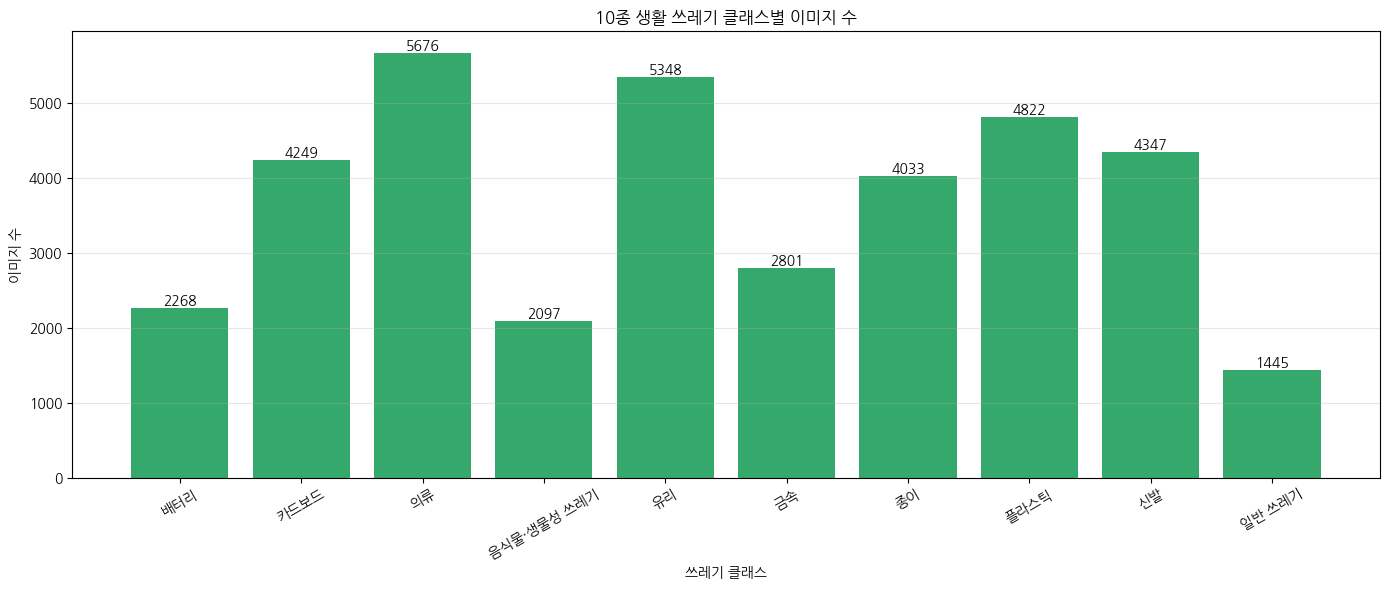

15. 클래스 분포 출력 완료



In [ ]:

# ================================================================
# 15. 클래스 분포 막대그래프 출력
# ================================================================

print("15. 클래스별 이미지 분포를 출력합니다.")

graph_labels = [
    KOREAN_LABELS[
        class_name
    ]
    for class_name in FINAL_CLASSES
]

graph_counts = [
    class_counts[
        class_name
    ]
    for class_name in FINAL_CLASSES
]

plt.figure(
    figsize=(14, 6)
)

bars = plt.bar(
    graph_labels,
    graph_counts,
    color="#35a86b"
)

plt.title(
    "10종 생활 쓰레기 클래스별 이미지 수"
)

plt.xlabel(
    "쓰레기 클래스"
)

plt.ylabel(
    "이미지 수"
)

plt.xticks(
    rotation=30
)

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, count in zip(
    bars,
    graph_counts
):

    plt.text(
        bar.get_x()
        + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print("15. 클래스 분포 출력 완료\n")



In [ ]:

# ================================================================
# 16. 최종 데이터셋을 Google Drive에 저장
# ================================================================

print("16. 최종 데이터를 Google Drive에 저장합니다.")

# 이전 결과가 있으면 제거
if DRIVE_MERGED_DIR.exists():

    shutil.rmtree(
        DRIVE_MERGED_DIR
    )

# 새 결과 복사
shutil.copytree(
    MERGED_DIR,
    DRIVE_MERGED_DIR
)

print(
    "16-1. 최종 데이터 저장 위치:"
)

print(
    DRIVE_MERGED_DIR
)

print("16. Google Drive 저장 완료\n")
# 저장 완료된 폴더명 출력
print(f"저장 완료된 폴더명: {DRIVE_MERGED_DIR.name}")

# 추가: 저장된 하위 클래스 목록 확인
saved_classes = [p.name for p in DRIVE_MERGED_DIR.iterdir() if p.is_dir()]
print(f"저장된 클래스 목록 ({len(saved_classes)}개): {saved_classes}")

16. 최종 데이터를 Google Drive에 저장합니다.
16-1. 최종 데이터 저장 위치:
/content/drive/MyDrive/CNN_Garbage_TEST/merged_10class
16. Google Drive 저장 완료

저장 완료된 폴더명: merged_10class
저장된 클래스 목록 (10개): ['shoes', 'trash', 'battery', 'paper', 'cardboard', 'metal', 'biological', 'plastic', 'glass', 'clothes']


In [ ]:

# ================================================================
# 17. TensorFlow 훈련·검증 데이터 생성
# ================================================================

print("17. TensorFlow 데이터셋을 생성합니다.")

# 17-1. 이미지 크기
IMG_HEIGHT = 180
IMG_WIDTH = 180

# 17-2. 한 번에 처리할 이미지 수: 예를 들어 전체 데이터가 320장이라면, 32장씩 총 10번에 걸쳐 나누어 학습을 진행합니다.
BATCH_SIZE = 32

# 17-3. 동일한 데이터 분리를 위한 난수:데이터를 훈련용(80%)과 검증용(20%)으로 무작위로 나눌 때, 시드(SEED) 값이 없으면 코드를 실행할 때마다 데이터를 섞는 결과가 매번 달라집니다.
SEED = 123


# ----------------------------------------------------------------
# 17-4. 훈련 데이터 생성: 전체의 80%
# ----------------------------------------------------------------

train_ds = (
    tf.keras.utils
    .image_dataset_from_directory(
        str(MERGED_DIR),
        validation_split=0.2,
        subset="training",
        seed=SEED,
        image_size=(
            IMG_HEIGHT,
            IMG_WIDTH
        ),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        label_mode="int",
        shuffle=True
    )
)


# ----------------------------------------------------------------
# 17-5. 검증 데이터 생성: 전체의 20%
# ----------------------------------------------------------------

val_ds = (
    tf.keras.utils
    .image_dataset_from_directory(
        str(MERGED_DIR),
        validation_split=0.2,
        subset="validation",
        seed=SEED,
        image_size=(
            IMG_HEIGHT,
            IMG_WIDTH
        ),
        batch_size=BATCH_SIZE,
        color_mode="rgb",
        label_mode="int",
        shuffle=True
    )
)

# ----------------------------------------------------------------
# 17-6. 실제 클래스 이름과 클래스 개수
# ----------------------------------------------------------------

class_names = (
    train_ds.class_names
)

num_classes = len(
    class_names
)

print(
    "\n17-6-1. TensorFlow 클래스 순서:"
)

for index, class_name in enumerate(
    class_names
):

    print(
        f"{index:2d} → "
        f"{class_name:10s} → "
        f"{KOREAN_LABELS.get(class_name, class_name)}"
    )

print(
    "\n17-6-2. 클래스 개수:",
    num_classes
)

if num_classes != 10:

    raise ValueError(
        f"클래스가 10개가 아닙니다. "
        f"현재 클래스 수: {num_classes}"
    )

print("17. TensorFlow 데이터 생성 완료\n")



17. TensorFlow 데이터셋을 생성합니다.
Found 37086 files belonging to 10 classes.
Using 29669 files for training.
Found 37086 files belonging to 10 classes.
Using 7417 files for validation.

17-6-1. TensorFlow 클래스 순서:
 0 → battery    → 배터리
 1 → biological → 음식물·생물성 쓰레기
 2 → cardboard  → 카드보드
 3 → clothes    → 의류
 4 → glass      → 유리
 5 → metal      → 금속
 6 → paper      → 종이
 7 → plastic    → 플라스틱
 8 → shoes      → 신발
 9 → trash      → 일반 쓰레기

17-6-2. 클래스 개수: 10
17. TensorFlow 데이터 생성 완료



In [ ]:

# ================================================================
# 18. 데이터 처리 속도 최적화
# ================================================================

print("18. 데이터 처리 속도를 최적화합니다.")
# 버퍼 크기나 데이터 로딩 병렬화 수치를 TensorFlow가 자동으로 계산하여 설정
AUTOTUNE = (
    tf.data.AUTOTUNE
)

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(
        buffer_size=AUTOTUNE
    )
)
# 학습과 데이터 조달이 동시에 병렬로 이루어져 GPU 대기 시간을 줄이고 학습 병목 현상을 해결
val_ds = (
    val_ds
    .cache()
    .prefetch(
        buffer_size=AUTOTUNE
    )
)

print("18. 데이터 처리 속도 최적화 완료\n")



18. 데이터 처리 속도를 최적화합니다.
18. 데이터 처리 속도 최적화 완료



# 하나의 Python 파일로 작성
**merged_10class 폴더 기반**으로 클래스별 데이터 수 및 불균형 비율을 진단하고 데이터 편향 설명 주석을 작성한 후, **70:15:15** 계층 분할 및 훈련 데이터 기준 클래스 가중치 자동 계산, 데이터 증강, **4개 합성곱 블록 CNN 모델 학습**, 학습 곡선 시각화, 클래스별 Precision·Recall·Macro F1 평가 및 혼동행렬 생성, 모델과 클래스 순서 저장, 휴대폰 촬영 이미지 전처리 및 예측, 그리고 검수한 사진을 정답 폴더에 추가하는 전체 파이프라인을 구축합니다.

2-1. 클래스 순서
 0 → battery    → 배터리
 1 → biological → 음식물·생물성 쓰레기
 2 → cardboard  → 카드보드
 3 → clothes    → 의류
 4 → glass      → 유리
 5 → metal      → 금속
 6 → paper      → 종이
 7 → plastic    → 플라스틱
 8 → shoes      → 신발
 9 → trash      → 일반 쓰레기

2-3. 클래스별 전체 이미지 수
battery   :   2268장
biological:   2097장
cardboard :   4249장
clothes   :   5676장
glass     :   5348장
metal     :   2801장
paper     :   4033장
plastic   :   4822장
shoes     :   4347장
trash     :   1445장

3-1. 클래스 불균형 진단
가장 많은 클래스: clothes 5676장
가장 적은 클래스: trash 1445장
불균형 비율: 3.93배
3-2. 불균형: 부족한 실제 사진 추가와 클래스 가중치가 필요합니다.


/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:219: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt

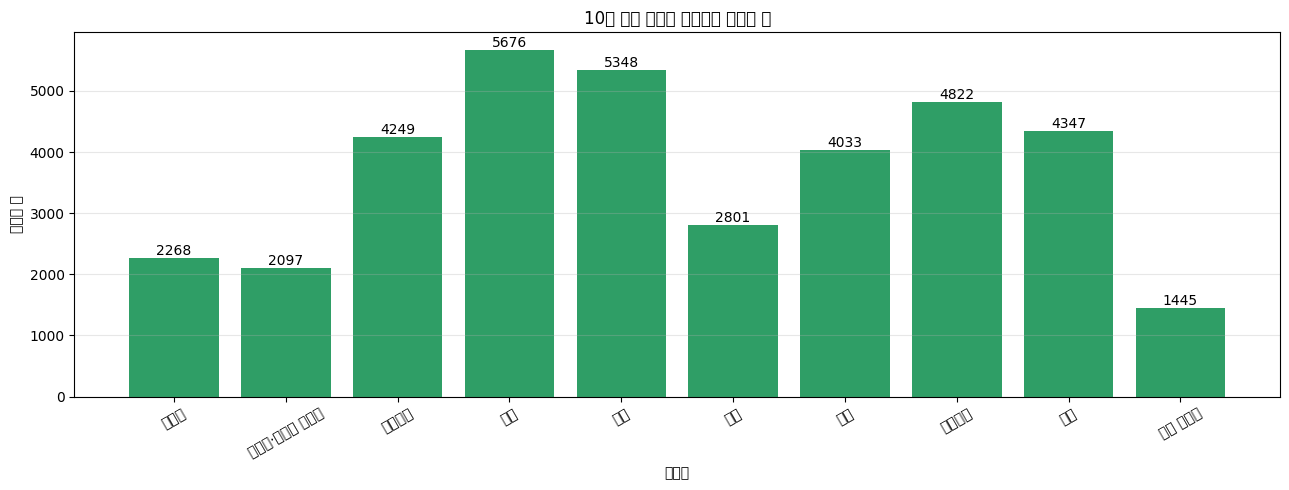


4. 데이터 분할
훈련 데이터:  25960장
검증 데이터:   5563장
테스트 데이터:   5563장

5-2. 클래스별 훈련 개수와 가중치
 0 battery   :   1588장, 가중치 1.635
 1 biological:   1468장, 가중치 1.768
 2 cardboard :   2974장, 가중치 0.873
 3 clothes   :   3973장, 가중치 0.653
 4 glass     :   3744장, 가중치 0.693
 5 metal     :   1961장, 가중치 1.324
 6 paper     :   2823장, 가중치 0.920
 7 plastic   :   3375장, 가중치 0.769
 8 shoes     :   3043장, 가중치 0.853
 9 trash     :   1011장, 가중치 2.568


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 11, 11, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,602 (1.61 MB)

 Trainable params: 422,602 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 103s 117ms/step - accuracy: 0.2236 - loss: 2.0444 - val_accuracy: 0.3110 - val_loss: 1.9183 - learning_rate: 0.0010
Epoch 2/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 128s 107ms/step - accuracy: 0.3492 - loss: 1.8037 - val_accuracy: 0.4104 - val_loss: 1.6701 - learning_rate: 0.0010
Epoch 3/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 75s 92ms/step - accuracy: 0.4242 - loss: 1.6303 - val_accuracy: 0.4375 - val_loss: 1.6206 - learning_rate: 0.0010
Epoch 4/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 85s 105ms/step - accuracy: 0.4767 - loss: 1.4857 - val_accuracy: 0.5111 - val_loss: 1.4488 - learning_rate: 0.0010
Epoch 5/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 78s 96ms/step - accuracy: 0.5193 - loss: 1.3803 - val_accuracy: 0.5400 - val_loss: 1.3506 - learning_rate: 0.0010
Epoch 6/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 77s 94ms/step - accuracy: 0.5491 - loss: 1.2875 - val_accuracy: 0.6035 - val_loss: 1.1947 - learning_rate: 0.0010
Epoch 7/20
812/812 ━━━━━━━━━━━━━━━━━━━━ 76s 93ms/step - accuracy: 0.575

/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:474: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  plt.t

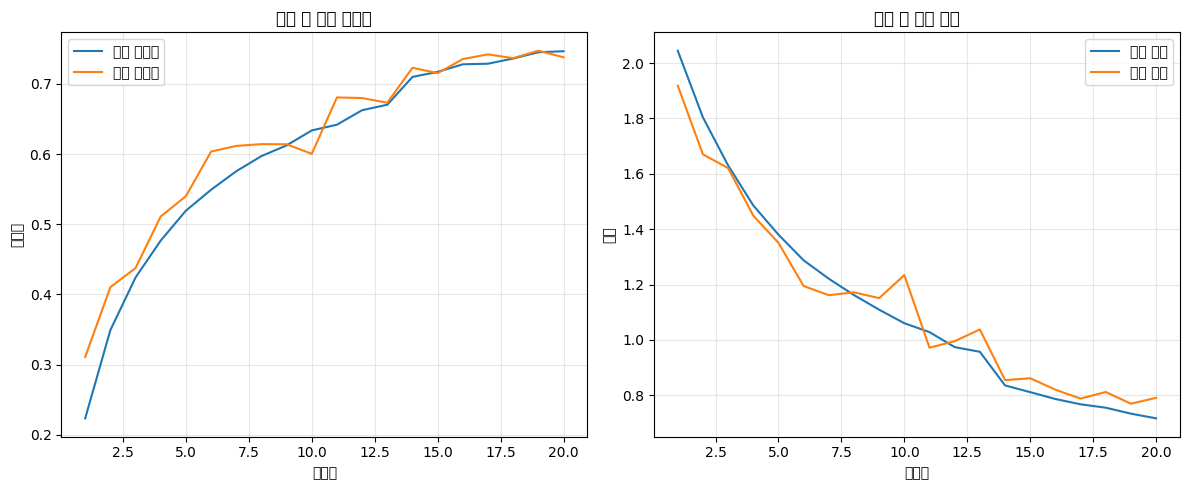

174/174 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.7498 - loss: 0.7654
11-1. 테스트 손실: 0.7654
11-1. 테스트 정확도: 0.7498

11-3. 클래스별 분류 보고서
              precision    recall  f1-score   support

         배터리     0.7525    0.9029    0.8209       340
 음식물·생물성 쓰레기     0.9081    0.7866    0.8430       314
        카드보드     0.7616    0.8226    0.7909       637
          의류     0.8472    0.8592    0.8531       852
          유리     0.8916    0.6359    0.7424       802
          금속     0.5747    0.7786    0.6613       420
          종이     0.5932    0.7835    0.6752       605
        플라스틱     0.7981    0.5677    0.6634       724
          신발     0.8207    0.7301    0.7727       652
      일반 쓰레기     0.5507    0.7512    0.6355       217

    accuracy                         0.7498      5563
   macro avg     0.7498    0.7618    0.7458      5563
weighted avg     0.7722    0.7498    0.7511      5563



/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14615/281437156.py:533: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt

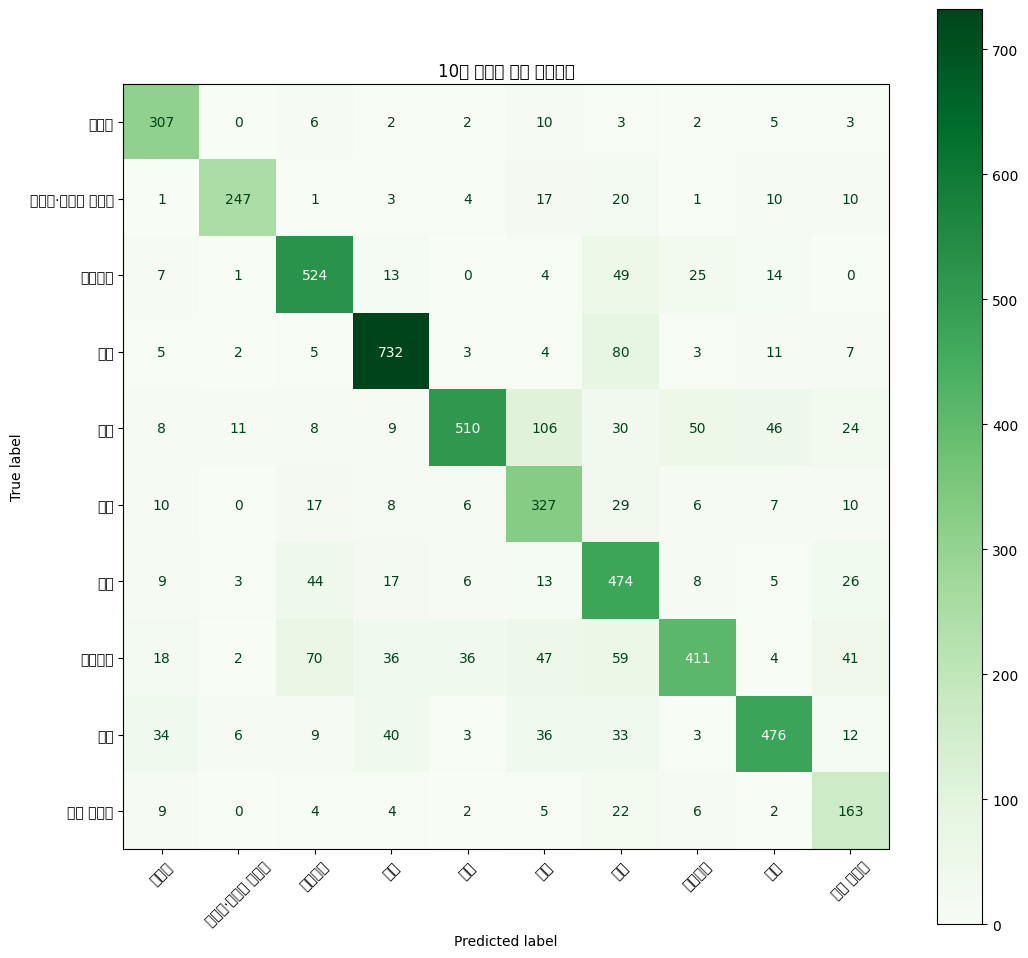

12-1. 모델 저장 완료: /content/drive/MyDrive/CNN_Garbage_TEST/garbage_10class_cnn.keras
12-2. 클래스 이름 저장 완료: /content/drive/MyDrive/CNN_Garbage_TEST/garbage_10class_labels.txt

16. 전체 과정 완료
저장 모델: /content/drive/MyDrive/CNN_Garbage_TEST/garbage_10class_cnn.keras
휴대폰 예측을 실행하려면 RUN_PHONE_PREDICTION = True로 변경하세요.


In [ ]:
"""
10종 생활 쓰레기 CNN: 데이터 편향 보정부터 휴대폰 사진 활용까지

Colab 사용 순서
1. 앞 단계에서 두 Kaggle 데이터셋을 merged_10class 폴더로 병합한다.
2. 이 파일을 Colab에 업로드하거나 셀에 붙여 넣는다.
3. DATA_DIR와 MODEL_PATH를 자신의 Google Drive 경로에 맞춘다.
4. 위에서 아래로 실행한다.

최종 클래스(폴더 이름 알파벳순)
battery, cardboard, clothes, food, glass,
metal, paper, plastic, shoes, trash

중요
- 클래스별 이미지 수가 달라도 모델은 만들 수 있다.
- 차이가 너무 크면 이미지가 많은 클래스를 자주 고르는 데이터 편향이 생길 수 있다.
- 클래스 가중치는 훈련 데이터의 개수만으로 계산한다.
- 검증·테스트 데이터에는 증강이나 클래스 가중치를 적용하지 않는다.
- Kaggle 사진과 거의 같은 사진이 훈련·테스트에 동시에 들어가면 성능이 부풀려질 수 있다.
"""


# ============================================================================
# 1. 라이브러리와 기본 설정
# ============================================================================

# 1-1. 필요한 라이브러리
from pathlib import Path
from datetime import datetime
import hashlib
import shutil

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


# 1-2. 재현 가능한 결과를 위한 난수 고정
SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)


# 1-3. 병합된 10종 데이터 폴더
# Google Drive를 연결했다면 아래 경로를 사용한다.
DATA_DIR = Path(
    "/content/drive/MyDrive/CNN_Garbage_TEST/merged_10class"
)


# 1-4. 모델 저장 경로
MODEL_PATH = Path(
    "/content/drive/MyDrive/CNN_Garbage_TEST/garbage_10class_cnn.keras"
)


# 1-5. 학생 휴대폰 사진을 저장할 별도 폴더
STUDENT_PHOTO_DIR = Path(
    "/content/drive/MyDrive/CNN_Garbage_TEST/student_photos"
)


# 1-6. 이미지와 학습 설정
IMG_HEIGHT = 180
IMG_WIDTH = 180
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32
EPOCHS = 20


# 1-7. 지원 이미지 확장자
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}


# 1-8. 한글 클래스 이름
KOREAN_LABELS = {
    "battery": "배터리",
    "cardboard": "카드보드",
    "clothes": "의류",
    "biological": "음식물·생물성 쓰레기",
    "glass": "유리",
    "metal": "금속",
    "paper": "종이",
    "plastic": "플라스틱",
    "shoes": "신발",
    "trash": "일반 쓰레기",
}


# 1-9. 필수 폴더 확인
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"병합 데이터 폴더가 없습니다: {DATA_DIR}\n"
        "DATA_DIR를 실제 merged_10class 위치로 수정하세요."
    )

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
STUDENT_PHOTO_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================================
# 2. 클래스와 이미지 개수 확인
# ============================================================================

# 2-1. 폴더 이름을 클래스 이름으로 사용한다.
class_names = sorted(
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir()
)

if len(class_names) != 10:
    raise ValueError(
        f"클래스가 10개가 아닙니다. 현재 클래스: {class_names}"
    )

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("2-1. 클래스 순서")
for index, class_name in enumerate(class_names):
    print(f"{index:2d} → {class_name:10s} → {KOREAN_LABELS[class_name]}")


# 2-2. 전체 이미지 경로와 라벨을 수집한다.
all_paths = []
all_labels = []

for class_name in class_names:
    class_dir = DATA_DIR / class_name

    for image_path in sorted(class_dir.rglob("*")):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            all_paths.append(str(image_path))
            all_labels.append(class_to_index[class_name])

all_paths = np.array(all_paths)
all_labels = np.array(all_labels, dtype=np.int32)

if len(all_paths) == 0:
    raise ValueError("학습할 이미지가 없습니다.")


# 2-3. 클래스별 전체 이미지 수를 계산한다.
class_counts = {
    class_name: int(np.sum(all_labels == class_to_index[class_name]))
    for class_name in class_names
}

print("\n2-3. 클래스별 전체 이미지 수")
for class_name in class_names:
    print(f"{class_name:10s}: {class_counts[class_name]:6d}장")


# ============================================================================
# 3. 클래스 불균형과 데이터 편향 진단
# ============================================================================

# 3-1. 최대/최소 클래스 비율을 구한다.
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)
max_count = class_counts[max_class]
min_count = class_counts[min_class]

if min_count == 0:
    raise ValueError(f"이미지가 없는 클래스가 있습니다: {min_class}")

imbalance_ratio = max_count / min_count

print("\n3-1. 클래스 불균형 진단")
print(f"가장 많은 클래스: {max_class} {max_count}장")
print(f"가장 적은 클래스: {min_class} {min_count}장")
print(f"불균형 비율: {imbalance_ratio:.2f}배")


# 3-2. 실습용 판단 기준을 출력한다.
if imbalance_ratio <= 1.5:
    imbalance_message = "양호: 그대로 학습하되 클래스별 성능을 확인합니다."
elif imbalance_ratio <= 2.0:
    imbalance_message = "보통: 데이터 증강과 클래스별 평가를 사용합니다."
elif imbalance_ratio <= 3.0:
    imbalance_message = "주의: 클래스 가중치 적용을 권장합니다."
elif imbalance_ratio <= 5.0:
    imbalance_message = "불균형: 부족한 실제 사진 추가와 클래스 가중치가 필요합니다."
else:
    imbalance_message = "심한 불균형: 데이터 추가 수집과 재구성이 필요합니다."

print("3-2.", imbalance_message)


# 3-3. 분포 그래프를 출력한다.
plt.figure(figsize=(13, 5))
bars = plt.bar(
    [KOREAN_LABELS[name] for name in class_names],
    [class_counts[name] for name in class_names],
    color="#2f9e66",
)
plt.title("10종 생활 쓰레기 클래스별 이미지 수")
plt.xlabel("클래스")
plt.ylabel("이미지 수")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

for bar, count in zip(bars, [class_counts[name] for name in class_names]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


# 3-4. 이미지 수 외에도 확인해야 하는 편향
# - 배경 편향: 특정 클래스가 항상 같은 배경에서 촬영되었는가?
# - 출처 편향: 데이터셋 1과 2의 촬영 방식이 지나치게 다른가?
# - 중복 편향: 같은 이미지가 훈련과 테스트에 동시에 들어갔는가?
# - 라벨 편향: biological을 food로 바꾸는 기준이 일관적인가?


# ============================================================================
# 4. 훈련 70%, 검증 15%, 테스트 15% 계층 분할
# ============================================================================

# 4-1. 첫 분할: 훈련 70%, 임시 데이터 30%
# stratify를 사용해 모든 분할에 클래스 비율을 비슷하게 유지한다.
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.30,
    random_state=SEED,
    stratify=all_labels,
)


# 4-2. 두 번째 분할: 임시 데이터 30%를 검증 15%, 테스트 15%로 나눈다.
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels,
)

print("\n4. 데이터 분할")
print(f"훈련 데이터: {len(train_paths):6d}장")
print(f"검증 데이터: {len(val_paths):6d}장")
print(f"테스트 데이터: {len(test_paths):6d}장")


# ============================================================================
# 5. 훈련 데이터만으로 클래스 가중치 계산
# ============================================================================

# 5-1. 테스트 정보가 학습에 새어 들어가지 않도록 훈련 개수만 사용한다.
train_class_counts = {
    class_name: int(np.sum(train_labels == class_to_index[class_name]))
    for class_name in class_names
}


# 5-2. 가중치 공식
# 전체 훈련 이미지 수 / (클래스 수 × 해당 클래스의 훈련 이미지 수)
class_weight = {}
number_of_classes = len(class_names)
number_of_train_images = len(train_paths)

for class_index, class_name in enumerate(class_names):
    count = train_class_counts[class_name]

    if count == 0:
        raise ValueError(f"훈련 데이터에 {class_name} 클래스가 없습니다.")

    class_weight[class_index] = (
        number_of_train_images / (number_of_classes * count)
    )

print("\n5-2. 클래스별 훈련 개수와 가중치")
for class_index, class_name in enumerate(class_names):
    print(
        f"{class_index:2d} {class_name:10s}: "
        f"{train_class_counts[class_name]:6d}장, "
        f"가중치 {class_weight[class_index]:.3f}"
    )


# ============================================================================
# 6. TensorFlow 입력 파이프라인
# ============================================================================

# 6-1. 파일을 읽고 RGB 이미지로 변환한 뒤 180×180으로 맞춘다.
def load_and_preprocess_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)

    # 여기에서는 255로 나누지 않는다.
    # 모델 내부의 Rescaling(1/255) 층이 정규화를 담당한다.
    return image, label


# 6-2. 경로와 라벨로 tf.data.Dataset을 만든다.
def make_dataset(paths, labels, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds = make_dataset(val_paths, val_labels, training=False)
test_ds = make_dataset(test_paths, test_labels, training=False)


# ============================================================================
# 7. 데이터 증강
# ============================================================================

# 7-1. 증강은 훈련 시에만 자동으로 활성화된다.
# 검증·테스트·실제 예측에서는 비활성화된다.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomTranslation(0.10, 0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)


# 7-2. 증강은 실제 새 정보를 만드는 것이 아니다.
# 이미지가 적은 클래스는 학생들이 실제 휴대폰 사진을 추가하는 것이 가장 좋다.


# ============================================================================
# 8. 4개 합성곱 블록의 CNN 모델
# ============================================================================

num_classes = len(class_names)

model = tf.keras.Sequential(
    [
        tf.keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

        # 8-1. 훈련할 때만 이미지 증강
        data_augmentation,

        # 8-2. 픽셀값 0~255를 0~1로 정규화
        tf.keras.layers.Rescaling(1.0 / 255),

        # 8-3. 합성곱 블록 1
        tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # 8-4. 합성곱 블록 2
        tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # 8-5. 합성곱 블록 3
        tf.keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # 8-6. 합성곱 블록 4
        tf.keras.layers.Conv2D(256, 3, padding="same", activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        # 8-7. 분류 부분
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.40),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(num_classes, activation="softmax"),
    ]
)


# 8-8. 모델 컴파일
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


# ============================================================================
# 9. 과대적합 방지 콜백과 클래스 가중치 학습
# ============================================================================

# 9-1. 검증 손실이 개선되지 않으면 조기 종료한다.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)


# 9-2. 검증 손실이 정체되면 학습률을 줄인다.
reduce_learning_rate = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)


# 9-3. 클래스 가중치는 훈련 손실 계산에만 사용된다.
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight,
    callbacks=[early_stopping, reduce_learning_rate],
)


# ============================================================================
# 10. 학습 곡선 확인
# ============================================================================

epochs_range = range(1, len(history.history["accuracy"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history["accuracy"], label="훈련 정확도")
plt.plot(epochs_range, history.history["val_accuracy"], label="검증 정확도")
plt.xlabel("에포크")
plt.ylabel("정확도")
plt.title("훈련 및 검증 정확도")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history["loss"], label="훈련 손실")
plt.plot(epochs_range, history.history["val_loss"], label="검증 손실")
plt.xlabel("에포크")
plt.ylabel("손실")
plt.title("훈련 및 검증 손실")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================================
# 11. 테스트 데이터 평가
# ============================================================================

# 11-1. 테스트 손실과 정확도
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"11-1. 테스트 손실: {test_loss:.4f}")
print(f"11-1. 테스트 정확도: {test_accuracy:.4f}")


# 11-2. 모든 테스트 이미지의 예측값을 계산한다.
true_labels = []
predicted_labels = []

for image_batch, label_batch in test_ds:
    probability_batch = model.predict(image_batch, verbose=0)
    prediction_batch = np.argmax(probability_batch, axis=1)

    true_labels.extend(label_batch.numpy().tolist())
    predicted_labels.extend(prediction_batch.tolist())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)


# 11-3. 클래스별 Precision, Recall, F1-score
# 불균형 데이터에서는 전체 정확도뿐 아니라 macro avg의 F1-score를 확인한다.
print("\n11-3. 클래스별 분류 보고서")
print(
    classification_report(
        true_labels,
        predicted_labels,
        labels=np.arange(num_classes),
        target_names=[KOREAN_LABELS[name] for name in class_names],
        digits=4,
        zero_division=0,
    )
)


# 11-4. 혼동행렬
# 행은 실제 클래스이고 열은 모델이 예측한 클래스이다.
cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(num_classes),
)

fig, ax = plt.subplots(figsize=(11, 10))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[KOREAN_LABELS[name] for name in class_names],
)
display.plot(ax=ax, cmap="Greens", xticks_rotation=45, values_format="d")
plt.title("10종 쓰레기 분류 혼동행렬")
plt.tight_layout()
plt.show()


# ============================================================================
# 12. 모델과 클래스 이름 저장
# ============================================================================

# 12-1. Keras 모델 저장
model.save(MODEL_PATH)
print(f"12-1. 모델 저장 완료: {MODEL_PATH}")


# 12-2. 웹앱과 재사용 시 클래스 순서를 잃지 않도록 텍스트로 저장
CLASS_NAMES_PATH = MODEL_PATH.with_name("garbage_10class_labels.txt")
CLASS_NAMES_PATH.write_text("\n".join(class_names), encoding="utf-8")
print(f"12-2. 클래스 이름 저장 완료: {CLASS_NAMES_PATH}")


# ============================================================================
# 13. 휴대폰 촬영 이미지 전처리 및 예측 함수
# ============================================================================

def predict_phone_image(
    image_path,
    trained_model=model,
    model_has_rescaling=True,
):
    """휴대폰 사진 한 장을 모델 입력 형태로 바꾸고 예측한다."""

    image_path = Path(image_path)

    # 13-1. 휴대폰 EXIF 회전정보를 적용한다.
    with Image.open(image_path) as image:
        image = ImageOps.exif_transpose(image)
        image = image.convert("RGB")
        display_image = image.copy()
        resized_image = image.resize(IMAGE_SIZE)

    # 13-2. PIL 이미지를 실수형 NumPy 배열로 바꾼다.
    image_array = np.array(resized_image, dtype=np.float32)

    # 13-3. 모델 안에 Rescaling이 없는 경우에만 외부에서 정규화한다.
    if not model_has_rescaling:
        image_array = image_array / 255.0

    # 13-4. (180, 180, 3)을 (1, 180, 180, 3)으로 바꾼다.
    input_tensor = np.expand_dims(image_array, axis=0)

    # 13-5. 10개 클래스 확률을 계산한다.
    probabilities = trained_model.predict(input_tensor, verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    predicted_class = class_names[predicted_index]
    confidence = float(probabilities[predicted_index])

    sorted_results = sorted(
        [
            {
                "index": index,
                "class": class_names[index],
                "korean": KOREAN_LABELS[class_names[index]],
                "probability": float(probability),
            }
            for index, probability in enumerate(probabilities)
        ],
        key=lambda item: item["probability"],
        reverse=True,
    )

    return {
        "image": display_image,
        "index": predicted_index,
        "class": predicted_class,
        "korean": KOREAN_LABELS[predicted_class],
        "confidence": confidence,
        "probabilities": probabilities,
        "sorted_results": sorted_results,
    }


# ============================================================================
# 14. Colab에서 휴대폰 사진 업로드 후 예측
# ============================================================================

# 14-1. 자동 실행 여부
# 학습 직후 휴대폰 사진을 시험하려면 True로 변경한다.
RUN_PHONE_PREDICTION = False

if RUN_PHONE_PREDICTION:
    from google.colab import files

    print("14-1. 휴대폰으로 촬영하거나 갤러리 사진을 선택하세요.")
    uploaded = files.upload()

    for uploaded_name in uploaded.keys():
        uploaded_path = Path("/content") / uploaded_name
        result = predict_phone_image(
            uploaded_path,
            trained_model=model,
            model_has_rescaling=True,
        )

        plt.figure(figsize=(6, 6))
        plt.imshow(result["image"])
        plt.title(
            f'예측: {result["korean"]}\n'
            f'신뢰도: {result["confidence"] * 100:.2f}%'
        )
        plt.axis("off")
        plt.show()

        print("14-2. 클래스별 예측 확률")
        for rank, item in enumerate(result["sorted_results"], start=1):
            print(
                f'{rank:2d}. {item["korean"]:15s}: '
                f'{item["probability"] * 100:6.2f}%'
            )

        if result["confidence"] < 0.60:
            print(
                "주의: 신뢰도가 낮습니다. 물체 하나만 중앙에서 밝게 촬영하세요."
            )


# ============================================================================
# 15. 사람이 확인한 휴대폰 사진을 정답 폴더에 추가하는 함수
# ============================================================================

def add_labeled_phone_image(image_path, true_class):
    """
    휴대폰 사진을 학생 촬영 데이터 폴더의 올바른 클래스에 저장한다.

    중요:
    모델의 예측을 그대로 정답으로 사용하지 않는다.
    학생 또는 교사가 실제 쓰레기 종류를 확인한 뒤 true_class를 입력한다.
    """

    if true_class not in class_names:
        raise ValueError(
            f"올바르지 않은 클래스입니다: {true_class}\n"
            f"선택 가능 클래스: {class_names}"
        )

    source_path = Path(image_path)
    target_dir = STUDENT_PHOTO_DIR / true_class
    target_dir.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    source_hash = hashlib.md5(
        source_path.read_bytes()
    ).hexdigest()[:10]
    target_path = target_dir / f"phone_{true_class}_{timestamp}_{source_hash}.jpg"

    # 원본 촬영 방향을 바로잡고 RGB JPEG로 저장한다.
    # 학습 시 180×180으로 자동 변환하므로 원본 해상도는 보존한다.
    with Image.open(source_path) as image:
        image = ImageOps.exif_transpose(image)
        image = image.convert("RGB")
        image.save(target_path, format="JPEG", quality=95)

    print(f"15-1. 정답 확인 사진 저장 완료: {target_path}")
    return target_path


# 15-2. 사용 예시
# 아래 주석을 해제하고 실제 파일 경로와 정답 클래스를 입력한다.
# saved_path = add_labeled_phone_image(
#     image_path="/content/phone_photo.jpg",
#     true_class="battery",
# )


# ============================================================================
# 16. 학생 촬영 데이터 운영 원칙
# ============================================================================

# 16-1. 학생 촬영 사진을 전부 훈련 데이터로 사용하지 않는다.
# 예: 학생 촬영 사진 100장 중 70장은 추가 훈련, 30장은 현실 환경 테스트에 사용한다.

# 16-2. 모델이 예측한 라벨을 사람이 확인하지 않고 학습에 넣으면 안 된다.
# 잘못된 예측이 다시 학습되면서 오류가 강화될 수 있다.

# 16-3. 학생 사진을 추가한 뒤에는 기존 모델이 자동으로 바뀌지 않는다.
# 병합 데이터에 검수한 학생 사진을 추가하고 다시 분할·학습해야 한다.

# 16-4. 촬영 권장 조건
# - 쓰레기 하나만 촬영한다.
# - 물체를 화면 중앙에 놓는다.
# - 밝은 곳에서 촬영한다.
# - 물체 전체가 보이게 한다.
# - 다양한 실제 배경에서도 일부 촬영한다.


print("\n16. 전체 과정 완료")
print(f"저장 모델: {MODEL_PATH}")
print("휴대폰 예측을 실행하려면 RUN_PHONE_PREDICTION = True로 변경하세요.")



In [ ]:
RUN_PHONE_PREDICTION = True

CNN 모델 불러오기 완료
사진 한 장을 촬영하거나 갤러리에서 선택하세요.


Saving 유리병.jpg to 유리병 (2).jpg
선택한 사진: /content/유리병 (2).jpg
모델 입력 형태: (1, 180, 180, 3)


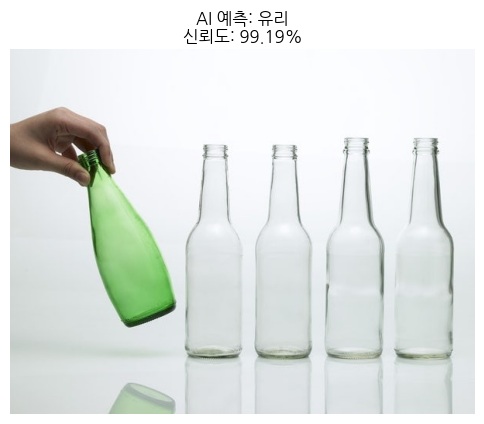

AI 예측 결과
영어 클래스: glass
한글 클래스: 유리
신뢰도: 99.19%

클래스별 예측 확률
 1. 유리             :  99.19%
 2. 신발             :   0.41%
 3. 플라스틱           :   0.23%
 4. 카드보드           :   0.08%
 5. 금속             :   0.05%
 6. 배터리            :   0.03%
 7. 의류             :   0.01%
 8. 일반 쓰레기         :   0.01%
 9. 종이             :   0.00%
10. 음식물·생물성 쓰레기    :   0.00%

판단: 신뢰도가 높은 예측입니다.


In [ ]:
# ================================================================
# 휴대폰 사진 한 장 분류
# 저장된 모델을 불러오므로 다시 학습하지 않음
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from PIL import Image, ImageOps
from pathlib import Path
from google.colab import files


# ---------------------------------------------------------------
# 1. 저장된 CNN 모델 불러오기
# ---------------------------------------------------------------

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "CNN_Garbage_TEST/"
    "garbage_10class_cnn.keras"
)

model = tf.keras.models.load_model(
    MODEL_PATH
)

print("CNN 모델 불러오기 완료")


# ---------------------------------------------------------------
# 2. 모델의 클래스 순서
# ---------------------------------------------------------------

class_names = [
    "battery",
    "cardboard",
    "clothes",
    "biological",
    "glass",
    "metal",
    "paper",
    "plastic",
    "shoes",
    "trash"
]

korean_labels = {
    "battery": "배터리",
    "cardboard": "카드보드",
    "clothes": "의류",
    "biological": "음식물·생물성 쓰레기",
    "glass": "유리",
    "metal": "금속",
    "paper": "종이",
    "plastic": "플라스틱",
    "shoes": "신발",
    "trash": "일반 쓰레기"
}


# ---------------------------------------------------------------
# 3. 휴대폰에서 사진 한 장 촬영 또는 선택
# ---------------------------------------------------------------

print(
    "사진 한 장을 촬영하거나 "
    "갤러리에서 선택하세요."
)

uploaded = files.upload()

if len(uploaded) == 0:
    raise ValueError(
        "업로드한 사진이 없습니다."
    )

# 첫 번째 사진 한 장만 사용
file_name = next(
    iter(uploaded.keys())
)

image_path = (
    Path("/content") /
    file_name
)

print("선택한 사진:", image_path)


# ---------------------------------------------------------------
# 4. 휴대폰 이미지 전처리
# ---------------------------------------------------------------

with Image.open(image_path) as image:

    # 휴대폰 사진의 회전정보 적용
    image = ImageOps.exif_transpose(
        image
    )

    # RGB 3채널로 통일
    image = image.convert(
        "RGB"
    )

    # 화면 출력용 원본 보관
    original_image = image.copy()

    # CNN 학습 크기와 동일하게 조정
    resized_image = image.resize(
        (180, 180)
    )

# 사진을 숫자 배열로 변환
image_array = np.array(
    resized_image,
    dtype=np.float32
)

# 사진 한 장을 배치 형태로 변환
# (180, 180, 3) → (1, 180, 180, 3)
input_tensor = np.expand_dims(
    image_array,
    axis=0
)

print(
    "모델 입력 형태:",
    input_tensor.shape
)


# ---------------------------------------------------------------
# 5. CNN 예측
# ---------------------------------------------------------------

probabilities = model.predict(
    input_tensor,
    verbose=0
)[0]

predicted_index = int(
    np.argmax(probabilities)
)

predicted_class = class_names[
    predicted_index
]

predicted_korean = korean_labels[
    predicted_class
]

confidence = float(
    probabilities[predicted_index]
)


# ---------------------------------------------------------------
# 6. 촬영 이미지와 결과 출력
# ---------------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.imshow(
    original_image
)

plt.title(
    f"AI 예측: {predicted_korean}\n"
    f"신뢰도: {confidence * 100:.2f}%"
)

plt.axis("off")
plt.show()

print("=" * 45)
print("AI 예측 결과")
print("=" * 45)
print("영어 클래스:", predicted_class)
print("한글 클래스:", predicted_korean)
print(
    "신뢰도:",
    f"{confidence * 100:.2f}%"
)


# ---------------------------------------------------------------
# 7. 모든 클래스의 예측 확률 출력
# ---------------------------------------------------------------

sorted_indices = np.argsort(
    probabilities
)[::-1]

print("\n클래스별 예측 확률")

for rank, index in enumerate(
    sorted_indices,
    start=1
):
    class_name = class_names[index]

    print(
        f"{rank:2d}. "
        f"{korean_labels[class_name]:15s}: "
        f"{probabilities[index] * 100:6.2f}%"
    )


# ---------------------------------------------------------------
# 8. 신뢰도에 따른 안내
# ---------------------------------------------------------------

if confidence >= 0.80:
    print(
        "\n판단: 신뢰도가 높은 예측입니다."
    )

elif confidence >= 0.60:
    print(
        "\n판단: 신뢰도가 보통입니다. "
        "다른 각도에서도 촬영해 보세요."
    )

else:
    print(
        "\n판단: 신뢰도가 낮습니다. "
        "밝은 곳에서 물체 하나만 다시 촬영하세요."
    )